# Robust Network Anomaly Detection: Binary Intrusion + Multi-Class Attack Classification using Gradient Boosting

## Abstract
This project develops a unified gradient boosting framework for network intrusion detection using a large-scale harmonized collection of CIC-IDS datasets (2017–2019) with two complementary objectives: (1) high-reliability binary anomaly detection (Benign vs. Any Attack) with near-perfect performance (AUC ≈ 0.997, Recall ≈ 0.958, F1 ≈ 0.972), and (2) multi-class attack classification across eight categories with strong overall accuracy (Weighted F1 ≈ 0.873) and reasonable balanced performance (Macro F1 ≈ 0.780 using LightGBM).

Results demonstrate that modern gradient boosting (particularly LightGBM) can effectively detect intrusions across diverse environments and attack types while providing actionable attack-type identification, making it suitable for real-world NIDS deployments where missing attacks is unacceptable.


## Introduction

Network intrusion detection systems (NIDS) must reliably detect attacks across different network environments, attack types, and time periods. 

The goal of this project is to train a single, unified gradient boosting model on the combined CIC collection (2017-2019) and evaluate its ability to detect anomalies and classify by Attack Type

The two objectives of this project:
1. Binary anomaly detection (Benign vs Any Intrusion). Priotized for real-world security where missing an attack (low recall) is far more costly than occasional false alarms.
2. Multi-Class attack Classification: to distinguish specific attack families (e.g., DDoS, DoS, Botnet, Bruteforce, Infiltration, Portscan, Webattack), enabling prioritized response and threat intelligence.

This work explores the feasibility of a streamlined, high-performance NIDS pipeline that supports both reliable alerting to intrusions and detailed attack characterization


## DataSet
The analysis uses a harmonized collection combining four benchmark datasets from the Canadian Institute for Cybersecurity, University of New Brunswick:
- CIC-IDS2017
- CIC-DoS2017
- CSE-CIC-IDS2018
- CIC-DDoS2019


**Data Citation**
> Canadian Institute for Cybersecurity, University of New Brunswick.  
> CIC-IDS2017, CIC-DoS2017, CSE-CIC-IDS2018, CIC-DDoS2019 datasets.  
> Available at: https://www.unb.ca/cic/datasets/index.html  
> Harmonized collection: https://www.kaggle.com/datasets/dhoogla/cicidscollection


## Evaltion Metrics

### Binary Anomaly Detection
Given the asymmetric cost of missing attacks in real-world security operations, primary emphasis is placed on:
- Recall (True Positive Rate): Proportion of actual attacks detected
- F1-score: Harmonic Mean of Precision and Recall
- AUC-ROC: Overall ranking ability
- Precision: How many flagged alerts are real attacks?

### Multi-Class Attack Classification
- Macro F1: Unweighted average F1-score across all classes (treats rare attacks equally)
- Weighted F1: Support-weighted average (reflects overall accuracy)
- Per-class Recall and Precision: To evaluate detection of rare attack types



## Reading and Preprocessing Data

In [1]:
# Cloud runtime setup: robust GPU detection + controlled parallelism
import os
import subprocess

CPU_THREADS = max(1, (os.cpu_count() or 2) - 1)
os.environ['OMP_NUM_THREADS'] = str(CPU_THREADS)
os.environ['MKL_NUM_THREADS'] = str(CPU_THREADS)
os.environ['NUMEXPR_NUM_THREADS'] = str(CPU_THREADS)
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(CPU_THREADS))

def _has_nvidia_gpu():
    try:
        out = subprocess.run(
            ['nvidia-smi', '-L'],
            capture_output=True, text=True, timeout=5, check=False
        )
        return out.returncode == 0 and 'GPU' in (out.stdout or '')
    except Exception:
        return False

HAS_GPU = _has_nvidia_gpu()
print(f'GPU detected (nvidia-smi): {HAS_GPU}')
print(f'CPU threads for parallel workloads: {CPU_THREADS}')

# Patch LightGBM / XGBoost train so later cells do not get stuck on CPU.
try:
    import lightgbm as lgb
    import numpy as np

    def _lightgbm_gpu_ready():
        if not HAS_GPU:
            return False
        try:
            test_X = np.random.rand(1024, 8).astype(np.float32)
            test_y = np.random.randint(0, 2, size=1024)
            d = lgb.Dataset(test_X, label=test_y)
            lgb.train(
                {'objective': 'binary', 'metric': 'auc', 'device': 'gpu', 'verbose': -1},
                d,
                num_boost_round=1
            )
            return True
        except Exception:
            return False

    LGB_DEVICE = 'gpu' if _lightgbm_gpu_ready() else 'cpu'

    if not getattr(lgb, '_cloud_patched_train', False):
        _orig_lgb_train = lgb.train
        def _patched_lgb_train(params, train_set, *args, **kwargs):
            p = dict(params or {})
            p['device'] = LGB_DEVICE
            p['num_threads'] = CPU_THREADS
            return _orig_lgb_train(p, train_set, *args, **kwargs)
        lgb.train = _patched_lgb_train
        lgb._cloud_patched_train = True

    print(f'LightGBM device: {LGB_DEVICE.upper()}')
except Exception as e:
    print(f'LightGBM patch skipped: {e}')

try:
    import xgboost as xgb

    if not getattr(xgb, '_cloud_patched_train', False):
        _orig_xgb_train = xgb.train
        def _patched_xgb_train(params, dtrain, *args, **kwargs):
            p = dict(params or {})
            p['nthread'] = CPU_THREADS
            if HAS_GPU:
                p.update({'tree_method': 'hist', 'device': 'cuda', 'predictor': 'gpu_predictor'})
                try:
                    return _orig_xgb_train(p, dtrain, *args, **kwargs)
                except Exception:
                    p.pop('device', None)
                    p['tree_method'] = 'gpu_hist'
                    p['predictor'] = 'gpu_predictor'
                    return _orig_xgb_train(p, dtrain, *args, **kwargs)
            p.update({'tree_method': 'hist', 'device': 'cpu', 'predictor': 'cpu_predictor'})
            return _orig_xgb_train(p, dtrain, *args, **kwargs)
        xgb.train = _patched_xgb_train
        xgb._cloud_patched_train = True

    print(f'XGBoost device: {"CUDA" if HAS_GPU else "CPU"}')
except Exception as e:
    print(f'XGBoost patch skipped: {e}')

GPU detected (nvidia-smi): True
CPU threads for parallel workloads: 255
LightGBM patch skipped: No module named 'lightgbm'
XGBoost device: CUDA


In [2]:
!pip install seaborn
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "cic-collection.parquet"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dhoogla/cicidscollection",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())
print(f"Loaded {len(df)} rows and {len(df.columns)} columns")

df.head()
print(f"Loaded {len(df)} rows and {len(df.columns)} columns")
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


/tmp/ipykernel_2061/3441251384.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 825M/825M [00:56<00:00, 15.2MB/s] 

Extracting zip of cic-collection.parquet...


First 5 records:    Flow Duration  Total Fwd Packets  Total Backward Packets  \
0              4                  2                       0   
1              1                  2                       0   
2              3                  2                       0   
3              1                  2                       0   
4            609                  7                       4   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                      12.0                       0.0                    6.0   
1                      12.0                       0.0                    6.0   
2                      12.0                       0.0                    6.0   
3                      12.0                       0.0                    6.0   
4                     484.0                     414.0                  233.0   

   Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  \
0                 6.00000               0.000000

,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Mean,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,ClassLabel
0,4,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,1,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,3,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,1,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,609,7,4,484.0,414.0,233.0,69.14286,111.967896,207.0,103.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign


### Preprocessing Dataset Standards

**Fixing Column Name Issues**:

To ensure consistency in column names and make it easier to correctly select columns by name, some code can be applied to remove whitespace, covert all letters to lower case, and replace spaces to '_'

**Handle Missing Values**

Thankfully this Dataset has already been cleaned to handle missing values, but it can be a good practice to check for NaNs, infinities and negatives in features that should not have them. A good practice to prevent the model from crashing during training



In [4]:
df.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Fwd Packets Length Total', 'Bwd Packets Length Total',
       'Fwd Packet Length Max', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count',
       'URG Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size',
       'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
       'Subflow Bwd Packets', 'Subflow Bwd By

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
df.columns

Index(['flow_duration', 'total_fwd_packets', 'total_backward_packets',
       'fwd_packets_length_total', 'bwd_packets_length_total',
       'fwd_packet_length_max', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes/s',
       'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max',
       'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std',
       'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean',
       'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags',
       'fwd_header_length', 'bwd_header_length', 'fwd_packets/s',
       'bwd_packets/s', 'packet_length_max', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'syn_flag_count',
       'urg_flag_count', 'avg_packet_size', 'avg_fwd_segment_size',
       'avg_bwd_segment_size', 'subflow_fwd_packets', 'subflow_fwd_bytes',
       'subflow_bwd_packets', 'subflow_bwd_by

In [6]:
def clean_dataset(df: pd.DataFrame, inplace: bool = False) -> pd.DataFrame:
    """Clean dataframe by removing rows that contain any NaN or inf values"""
    assert isinstance(df, pd.DataFrame), "Input must be a pandas DataFrame"
    df_clean = df if inplace else df.copy()
    df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_clean.dropna(inplace=True)
    
    if inplace:
        return None
    return df_clean

In [7]:
#df_clean = clean_dataset(df)
#print(f"Original rows: {len(df)}")
#print(f"Cleaned rows:  {len(df_clean)}")
#print(f"Rows removed:  {len(df) - len(df_clean)}")
print("Missing values:", df.isna().sum().sum())
print("Infinite values:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Missing values: 0
Infinite values: 0


In [8]:
#Remove columns that are constant
label_cols = ['label', 'classlabel']
constant_cols = [
    col for col in df.columns
    if df[col].nunique() <= 1 and col not in label_cols
]
print(f"Removing {len(constant_cols)} constant columns:")
print(constant_cols)
df.drop(columns=constant_cols, inplace=True)

print(f"\nRemaining columns: {len(df.columns)}")

Removing 0 constant columns:
[]

Remaining columns: 59


### Optimize Data Types
The original dataset uses int64 and float64 by default which are overkill for most network features.

We can reduce memory and speed up training by converting columns to the smallest possible integer/float types that preserve all values.

In this case, we reduce memory footprint from 3.7GB to 3GB. A 18.9% reduction.


In [9]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9167581 entries, 0 to 9167580
Data columns (total 59 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   flow_duration             int64  
 1   total_fwd_packets         int32  
 2   total_backward_packets    int32  
 3   fwd_packets_length_total  float64
 4   bwd_packets_length_total  float64
 5   fwd_packet_length_max     float64
 6   fwd_packet_length_mean    float32
 7   fwd_packet_length_std     float32
 8   bwd_packet_length_max     float64
 9   bwd_packet_length_mean    float32
 10  bwd_packet_length_std     float32
 11  flow_bytes/s              float64
 12  flow_packets/s            float64
 13  flow_iat_mean             float32
 14  flow_iat_std              float32
 15  flow_iat_max              float64
 16  flow_iat_min              float64
 17  fwd_iat_total             float64
 18  fwd_iat_mean              float32
 19  fwd_iat_std               float32
 20  fwd_iat_max             

In [10]:
label_cols = ['label', 'classlabel']

#Identify the columns that can be safely downcast
int_cols = df.select_dtypes(include=['int64', 'int32']).columns.drop(label_cols, errors='ignore')
float_cols = df.select_dtypes(include=['float64', 'float32']).columns

#Downcast Integers (int64 -> int32 or int8 where possible)
for col in int_cols:
    if df[col].max() <= 127 and df[col].min() >= -128:
        df[col] = df[col].astype('int8')
    else:
        df[col] = df[col].astype('int32')

#Downcast floats to float32
df[float_cols] = df[float_cols].astype('float32')

print("Memory usage after optimization:")
print(df.info(memory_usage='deep'))

Memory usage after optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9167581 entries, 0 to 9167580
Data columns (total 59 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   flow_duration             int32  
 1   total_fwd_packets         int32  
 2   total_backward_packets    int32  
 3   fwd_packets_length_total  float32
 4   bwd_packets_length_total  float32
 5   fwd_packet_length_max     float32
 6   fwd_packet_length_mean    float32
 7   fwd_packet_length_std     float32
 8   bwd_packet_length_max     float32
 9   bwd_packet_length_mean    float32
 10  bwd_packet_length_std     float32
 11  flow_bytes/s              float32
 12  flow_packets/s            float32
 13  flow_iat_mean             float32
 14  flow_iat_std              float32
 15  flow_iat_max              float32
 16  flow_iat_min              float32
 17  fwd_iat_total             float32
 18  fwd_iat_mean              float32
 19  fwd_iat_std               floa

## EDA - Understanding the Data
Before modeling, we can inspect class distributions, imbalances and feature stats to help spot issues and inform decisions like class weighting. 

Multi-Class Distribution (classlabel):
classlabel
Benign          78.39
DDoS            13.47
DoS              4.33
Botnet           1.59
Bruteforce       1.13
Infiltration     1.03
Webattack        0.03
Portscan         0.02
Name: proportion, dtype: float64


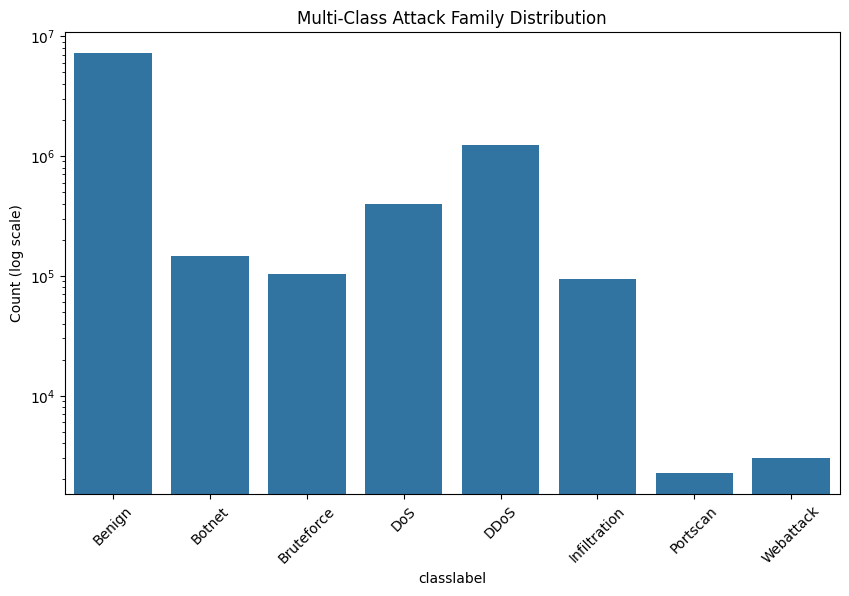


Feature Summary:
                                  mean           std           min  \
flow_duration             1.657195e+07  3.411205e+07 -2.101873e+09   
total_fwd_packets         4.079505e+01  2.066283e+03  0.000000e+00   
total_backward_packets    9.505221e+00  5.805652e+02  0.000000e+00   
fwd_packets_length_total  2.063827e+03  8.358580e+04  0.000000e+00   
bwd_packets_length_total  1.001084e+04  1.281297e+06  0.000000e+00   
fwd_packet_length_max     2.946960e+02  5.018536e+02  0.000000e+00   
fwd_packet_length_mean    8.127664e+01  1.422410e+02  0.000000e+00   
fwd_packet_length_std     1.043248e+02  1.989876e+02  0.000000e+00   
bwd_packet_length_max     6.070651e+02  1.180525e+03  0.000000e+00   
bwd_packet_length_mean    2.002887e+02  3.792937e+02  0.000000e+00   
bwd_packet_length_std     2.409867e+02  5.040440e+02  0.000000e+00   
flow_bytes/s              2.854876e+06  6.354385e+07 -2.610000e+08   
flow_packets/s            1.102920e+04  1.040547e+05 -2.000000e+06   
fl

In [11]:
print("Multi-Class Distribution (classlabel):")
print(df['classlabel'].value_counts(normalize=True).round(4) * 100)

#Plotting the Multi Class Imbalance
plt.figure(figsize=(10, 6))
sns.countplot(x='classlabel', data=df)
plt.title('Multi-Class Attack Family Distribution')
plt.xticks(rotation=45)
plt.ylabel('Count (log scale)')
plt.yscale('log')
plt.show()

#Feature Stats
print("\nFeature Summary:")
print(df.describe().T[['mean', 'std', 'min', 'max']])

## Label Encoding
Preparing the Binary and Multi-Class Targets

* Binary: Map 'Benign' to 0, everything else to 1
* Multi-Cass: Encode the 8 classlabel categories to integers (0-7) using LabelEnCoder

We create two new columns to keep the originals intact. No encoding needed for features

Binary is fast and practical for initial alerts while Multi-Class adds value by identifying attack types (such as DDoS vs Bruteforce)

In [12]:
from sklearn.preprocessing import LabelEncoder

#Binary Label
df['binary_label'] = df['classlabel'].apply(lambda x: 0 if x == 'Benign' else 1)


df['binary_label'].value_counts(normalize=True).round(4) * 100

binary_label
0    78.39
1    21.61
Name: proportion, dtype: float64

In [13]:
#Multi-Class Label
le = LabelEncoder()
df['multi_label'] = le.fit_transform(df['classlabel'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Benign': 0, 'Botnet': 1, 'Bruteforce': 2, 'DDoS': 3, 'DoS': 4, 'Infiltration': 5, 'Portscan': 6, 'Webattack': 7}


In [14]:
print(df[['classlabel', 'multi_label', 'binary_label']].head())

  classlabel  multi_label  binary_label
0     Benign            0             0
1     Benign            0             0
2     Benign            0             0
3     Benign            0             0
4     Benign            0             0


In [15]:
df

,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_mean,...,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,classlabel,binary_label,multi_label
0,4,2,0,12.0,0.0,6.0,6.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0
1,1,2,0,12.0,0.0,6.0,6.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0
2,3,2,0,12.0,0.0,6.0,6.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0
3,1,2,0,12.0,0.0,6.0,6.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0
4,609,7,4,484.0,414.0,233.0,69.142860,111.967896,207.0,103.500000,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9167576,44797921,6,5,36.0,0.0,6.0,6.000000,0.000000,0.0,0.000000,...,23727.0,23502.0,10000000.0,72.038765,10000000.0,10000000.0,Benign,Benign,0,0
9167577,49,3,0,76.0,0.0,45.0,25.333334,23.028967,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0
9167578,1286687,41,42,2664.0,6954.0,456.0,64.975609,109.864571,976.0,165.571426,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0
9167579,217,2,1,31.0,6.0,31.0,15.500000,21.920311,6.0,6.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Benign,0,0


In [16]:
df.columns

Index(['flow_duration', 'total_fwd_packets', 'total_backward_packets',
       'fwd_packets_length_total', 'bwd_packets_length_total',
       'fwd_packet_length_max', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes/s',
       'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max',
       'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std',
       'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean',
       'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags',
       'fwd_header_length', 'bwd_header_length', 'fwd_packets/s',
       'bwd_packets/s', 'packet_length_max', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'syn_flag_count',
       'urg_flag_count', 'avg_packet_size', 'avg_fwd_segment_size',
       'avg_bwd_segment_size', 'subflow_fwd_packets', 'subflow_fwd_bytes',
       'subflow_bwd_packets', 'subflow_bwd_by

### Data Splitting 
Using a random stratisfied split, we perform the split once for features (X) which is all features except labels

Then create seperate y for binary (which will use binary_label) and multi class (which will use multi_label). Keeping everything consistent

This split will be 70% Train, 15% Val, 15% Test

In [17]:
from sklearn.model_selection import train_test_split

#Features
X = df.drop(['label','classlabel','binary_label', 'multi_label'], axis=1,errors='ignore')

#Targets
y_bin = df['binary_label']
y_multi = df['multi_label']

#Split
X_train, X_temp, y_train_bin, y_temp_bin = train_test_split(
    X, y_bin, test_size=0.3, stratify=y_bin, random_state=42
)
X_val, X_test, y_val_bin, y_test_bin = train_test_split(
    X_temp, y_temp_bin, test_size=0.5, stratify=y_temp_bin, random_state=42
)

#Multi Class Splits use same X splits for a fair comparison
y_train_multi = y_multi.loc[X_train.index]
y_val_multi = y_multi.loc[X_val.index]
y_test_multi = y_multi.loc[X_test.index]


print(f"Train: {X_train.shape[0]} rows | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print("\nBinary Train Distribution:\n", y_train_bin.value_counts(normalize=True).round(4) * 100)
print("\nMulti-Class Train Distribution:\n", y_train_multi.value_counts(normalize=True).round(4) * 100)

Train: 6417306 rows | Val: 1375137 | Test: 1375138

Binary Train Distribution:
 binary_label
0    78.39
1    21.61
Name: proportion, dtype: float64

Multi-Class Train Distribution:
 multi_label
0    78.39
3    13.46
4     4.34
1     1.59
2     1.13
5     1.04
7     0.03
6     0.02
Name: proportion, dtype: float64


## Models Overview

### Light Gradient Boosting Machine (LightGBM)
Light Gradient Boosting Machine (LightGBM) is a open-source gradient boosting framework developed by Microsoft. LightGBM uses a leaf wise tree growth strategy (grows deepest leaf first) instead of level wise. Often leading to faster training and better accuracy with less memory

Strong with tabular data, handling categorical features natively and dealing with imbalances common in anomaly detection

**Important Hyperparameters**:
- `learning_rate`: step size (0.01–0.1)
- `num_leaves`: max leaves per tree (31–256)
- `max_depth`: tree depth limit (-1 = unlimited)
- `min_child_samples`: min samples per leaf
- `scale_pos_weight`: penalty for minority class (binary)

### XGBoost
The most widely used gradient-boosting library. Uses level wise (depth wise) tree growth with second order gradients and advanced regularization

**Key differences from LightGBM**:
- The tree growth is more conservative, can lead to better generalization on smaller datasets
- Slightly slower training but very competitive accuracy


**Important hyperparameters**:
- `max_depth`: usually lower (6–12) than LightGBM’s num_leaves
- `min_child_weight`: similar to min_child_samples
- `gamma`: minimum loss reduction for split
- `tree_method: 'gpu_hist'`: enables GPU

### Hyperparameter Tuning Strategy (Optuna)
Optuna will be used for Hyperparameter tuning with early stopping. For each task, 20-30 trials will be run optimizing validation AUC for Binary and validation macro-f1 for Multi Class

The best parameters from LightGBM are reused as a starting point for XGBoost to promote fair comparison

## Task 1: Binary Anomaly Detection (Benign vs Attack)
Security-critical task: maximize Recall (catch all attacks)

### LightGBM for Binary Anomaly Detection

In [18]:
#!pip install optuna-integration[lightgbm]

In [19]:
#Imports
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, confusion_matrix
#import optuna
#from optuna.integration import LightGBMPruningCallback, XGBoostPruningCallback
from tqdm.notebook import tqdm

ModuleNotFoundError: No module named 'lightgbm'

In [ ]:
#Convert to numpy
X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)

feature_names = X_train.columns.tolist() #For importance plots

#Binary Imbalance Weight
pos_weight = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()
print(f"Class imbalance weight: {pos_weight:.2f}")

assert not np.any(np.isinf(X.values)), "Still have inf!"
assert not np.any(np.isnan(X.values)), "Still have NaN!"

In [ ]:
#LightGBM Binary with Optuna Tuning

def lgb_bin(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 32, 256),
        'max_depth': trial.suggest_int('max_depth', 6, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'scale_pos_weight': pos_weight,
        'device': 'cpu',
        'verbose': -1,
        'seed': 42
    }

    train_data = lgb.Dataset(X_train_np, label=y_train_bin)
    val_data = lgb.Dataset(X_val_np, label=y_val_bin, reference=train_data)
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(50),
            LightGBMPruningCallback(trial, 'auc')
        ],
    )
    return roc_auc_score(y_val_bin, model.predict(X_val_np))

#Optuna Trials
#print("Running Optuna tuning for LightGBM (20 trials)...")
#study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
#study_lgb.optimize(lgb_bin, n_trials=20, show_progress_bar=True)

#print(f"Best LightGBM AUC: {study_lgb.best_value:.5f}")
#print("Best params:", study_lgb.best_params)

In [ ]:
import torch
#GPU Detection
device = 'gpu' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    device = 'gpu'
    print(f"GPU support")
else:
    device = 'cpu'
print(f"Using : {device.upper()} for LightGBM training")

#LightGBM Training
train_data = lgb.Dataset(X_train_np, label=y_train_bin, feature_name=feature_names)
val_data   = lgb.Dataset(X_val_np,   label=y_val_bin, reference=train_data)
params = {
    'objective': 'binary',
    'metric': 'auc',  # Primary metric
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'device': device,
    'scale_pos_weight': pos_weight,
    'verbose': 1,  # Shows progress every iteration
    'seed': 42
}



print("Training LightGBM model")
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,  # Allow more rounds
    valid_sets=[val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

val_pred = lgb_model.predict(X_val_np)
print(f"Validation AUC: {roc_auc_score(y_val_bin, val_pred):.5f}")
print(f"Validation Recall (thresh=0.5): {recall_score(y_val_bin, val_pred > 0.5):.5f}")

In [ ]:
lgb_model.save_model('lgb_binary_model.json')

In [ ]:
## Predictions and Evaluations
y_pred_prob = lgb_model.predict(X_test_np)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nLightGBM Binary Test Metrics")
print(f"AUC       : {roc_auc_score(y_test_bin, y_pred_prob):.5f}")
print(f"F1-score  : {f1_score(y_test_bin, y_pred):.5f}")
print(f"Recall    : {recall_score(y_test_bin, y_pred):.5f}")
print(f"Precision : {precision_score(y_test_bin, y_pred):.5f}")

In [ ]:
#Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test_bin, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('LightGBM – Binary Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
#Feature Importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_gain': lgb_model.feature_importance(importance_type='gain'),
    'importance_split': lgb_model.feature_importance(importance_type='split')
}).sort_values('importance_gain', ascending=False).reset_index(drop=True)

print("\nTop 15 Features by Gain")
print(importance_df[['feature', 'importance_gain']].head(15))

plt.figure(figsize=(10,8))
lgb.plot_importance(lgb_model, max_num_features=20, importance_type='gain')
plt.title('LightGBM – Top 20 Features (Gain)')
plt.show()

### XGBoost for Binary Anomaly Detection

In [ ]:
import xgboost as xgb
import torch
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix

#GPU Detection
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using tree_method: {device.upper()} for XGBoost training")

#XGBoost Parameters
params = {
    'objective': 'binary:logistic', 
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 8, 
    'min_child_weight': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': pos_weight,
    'tree_method': 'hist',
    'device':device,
    'seed': 42,
    'verbosity': 1
}

#Prepare DMatrix
dtrain = xgb.DMatrix(X_train_np, label=y_train_bin,feature_names=feature_names)
dval = xgb.DMatrix(X_val_np, label=y_val_bin, feature_names=feature_names)
dtest = xgb.DMatrix(X_test_np, label=y_test_bin, feature_names=feature_names)

#Early Stoping (watchlist for monitoring validation)
watchlist = [(dtrain, 'train'), (dval, 'val')]

print("Starting XGBoost training...")
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=2000, 
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=50
)

In [ ]:
#Save XGB Binary Model
xgb_model.save_model('xgb_binary_model.json')

In [ ]:
# Predict on validation set
val_pred = xgb_model.predict(dval)

# Key Metrics (prioritizing recall and F1 as per your project)
val_auc = roc_auc_score(y_val_bin, val_pred)
val_recall = recall_score(y_val_bin, (val_pred > 0.5).astype(int))
val_precision = precision_score(y_val_bin, (val_pred > 0.5).astype(int))
val_f1 = f1_score(y_val_bin, (val_pred > 0.5).astype(int))

print(f"Validation AUC: {val_auc:.5f}")
print(f"Validation Recall: {val_recall:.5f}")
print(f"Validation Precision: {val_precision:.5f}")
print(f"Validation F1: {val_f1:.5f}")

In [ ]:
xgb.plot_importance(xgb_model, max_num_features=20, importance_type='gain')
plt.title('XGBoost Feature Importance (Gain)')
plt.show()

### Evaluation of LightGBM and XGBoost for Binary Anomaly Detection

In [ ]:
lgb_pred_prob = lgb_model.predict(X_test_np)
lgb_pred = (lgb_pred_prob >= 0.5).astype(int)

lgb_test_auc = roc_auc_score(y_test_bin, lgb_pred_prob)
lgb_test_f1 = f1_score(y_test_bin, lgb_pred)
lgb_test_recall = recall_score(y_test_bin, lgb_pred)
lgb_test_precision = precision_score(y_test_bin, lgb_pred)

xgb_pred_prob = xgb_model.predict(dtest)
xgb_pred = (xgb_pred_prob > 0.5).astype(int)

xgb_test_auc = roc_auc_score(y_test_bin, xgb_pred_prob)
xgb_test_f1 = f1_score(y_test_bin, xgb_pred)
xgb_test_recall = recall_score(y_test_bin, xgb_pred)
xgb_test_precision = precision_score(y_test_bin, xgb_pred)

metrics_data = {
    'Metric': ['AUC', 'F1-score', 'Recall', 'Precision'],
    'LGBoost': [lgb_test_auc, lgb_test_f1, lgb_test_recall, lgb_test_precision],
    'XGBoost': [xgb_test_auc, xgb_test_f1, xgb_test_recall, xgb_test_precision]
}

binary_metrics = pd.DataFrame(metrics_data).set_index('Metric')
print("Model Comparison for Binary Anomaly Detection")
metrics_data

In [ ]:
#Feature Importance
#XGB
xgb_importance_gain = xgb_model.get_score(importance_type='gain')
xgb_importance_split = xgb_model.get_score(importance_type='total_cover')

xgb_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_gain': [xgb_importance_gain.get(f, 0) for f in feature_names],
    'importance_split': [xgb_importance_split.get(f, 0) for f in feature_names]
}).sort_values('importance_gain', ascending=False).reset_index(drop=True)

#Light GBM
lgb_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_gain': lgb_model.feature_importance(importance_type='gain'),
    'importance_split': lgb_model.feature_importance(importance_type='split')
}).sort_values('importance_gain', ascending=False).reset_index(drop=True)

#Combined Feature Importance (TOP 15 for each)
combined_importance = pd.merge(
    lgb_importance_df[['feature', 'importance_gain']].head(15).rename(columns={'importance_gain': 'LGB_Gain'}),
    xgb_importance_df[['feature', 'importance_gain']].head(15).rename(columns={'importance_gain': 'XGB_Gain'}),
    on='feature', how='outer'
).fillna(0).sort_values('LGB_Gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
#LightGBM
lgb.plot_importance(lgb_model, ax=axes[0], max_num_features=20, importance_type='gain')
axes[0].set_title('LightGBM – Top 20 Features (Gain)')

#XGBoost
xgb.plot_importance(xgb_model, ax=axes[1], max_num_features=20, importance_type='gain')
axes[1].set_title('XGBoost – Top 20 Features (Gain)')

plt.tight_layout()
plt.show()

In [ ]:
xgb_importance_df.head()

In [ ]:
lgb_importance_df.head()

## Task 2: Multi Class Attack Classification
Instead of binary, wewill use multi-class objectives.Models output probablities for each class

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
#Compute Class Weights
classes = np.unique(y_train_multi)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_multi)
class_weight_dict = dict(zip(classes, class_weights))
print("Class Weights:", class_weight_dict)
#With XGBoost Per-Sample weights
sample_weights_train = np.array([class_weight_dict[label] for label in y_train_multi])
sample_weights_val = np.array([class_weight_dict[label] for label in y_val_multi])

In [ ]:
#Light GBM Multi-Class Model
import lightgbm as lgb
import torch
from sklearn.metrics import f1_score, classification_report

#GPU
device = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device.upper()} for LightGBM training")
#Parameters
params = {
    'objective': 'multiclass',
    'num_class': 8,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 128,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'device': 'cpu',
    'seed': 42,
    'verbosity': -1
}
# Add weights to Dataset 
train_data = lgb.Dataset(X_train_np, label=y_train_multi, weight=sample_weights_train, feature_name=feature_names)
val_data = lgb.Dataset(X_val_np, label=y_val_multi, weight=sample_weights_val, reference=train_data)

print("Starting LightGBM Multi-Class Training...")
lgb_multi_model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)
lgb_multi_model.save_model('lgb_multi_model.txt')

In [ ]:
#LightGBM Evaluation
lgb_pred_prob = lgb_multi_model.predict(X_test_np)
lgb_pred = np.argmax(lgb_pred_prob, axis=1)

# Metrics
macro_f1 = f1_score(y_test_multi, test_pred, average='macro')
weighted_f1 = f1_score(y_test_multi, test_pred, average='weighted')

print("\nLightGBM Multi-Class Test Metrics")
print(f"Macro F1: {macro_f1:.5f}")
print(f"Weighted F1: {weighted_f1:.5f}")
print("\nPer-Class Report:\n", classification_report(y_test_multi, test_pred, target_names=le.classes_))

In [ ]:
import xgboost as xgb
import torch
from sklearn.metrics import f1_score, classification_report

#GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using tree_method: {device.upper()} for XGBoost training")

params = {
    'objective': 'multi:softprob',  # Multi-class probabilities
    'num_class': 8,
    'eval_metric': 'mlogloss',  # For training
    'learning_rate': 0.05,
    'max_depth': 8,
    'min_child_weight': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'device': device,
    'seed': 42,
    'verbosity': 1
}

#DMatrix
dtrain_multi = xgb.DMatrix(X_train_np, label=y_train_multi, feature_names=feature_names, weight=sample_weights_train)
dval_multi = xgb.DMatrix(X_val_np, label=y_val_multi, feature_names=feature_names, weight=sample_weights_val)
dtest_multi = xgb.DMatrix(X_test_np, label=y_test_multi, feature_names=feature_names)

watchlist = [(dtrain_multi, 'train'), (dval_multi, 'val')]

print("Starting XGBoost Multi-Class Training...")
xgb_multi_model = xgb.train(
    params,
    dtrain_multi,
    num_boost_round=2000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=50
)

xgb_multi_model.save_model('xgb_multi_model.json')

In [ ]:
from sklearn.metrics import f1_score, classification_report
import pandas as pd

# LightGBM Multi-Class Test Predictions
lgb_pred_prob = lgb_multi_model.predict(X_test_np)
lgb_pred = np.argmax(lgb_pred_prob, axis=1)

lgb_macro_f1 = f1_score(y_test_multi, lgb_pred, average='macro')
lgb_weighted_f1 = f1_score(y_test_multi, lgb_pred, average='weighted')

# XGBoost Multi-Class Test Predictions
xgb_pred_prob = xgb_multi_model.predict(dtest_multi)
xgb_pred = np.argmax(xgb_pred_prob, axis=1)

xgb_macro_f1 = f1_score(y_test_multi, xgb_pred, average='macro')
xgb_weighted_f1 = f1_score(y_test_multi, xgb_pred, average='weighted')

# Comparison DataFrame
metrics_data_multi = {
    'Metric': ['Macro F1', 'Weighted F1'],
    'LightGBM': [lgb_macro_f1, lgb_weighted_f1],
    'XGBoost': [xgb_macro_f1, xgb_weighted_f1]
}

multi_metrics_df = pd.DataFrame(metrics_data_multi).set_index('Metric').round(5)

## Multi Class Attack Classification Results
The multi-class task aims to classify network flows into one of eight specific categories, distinguishing not only benign from malicious traffic but also identifying the type of attack. 

LightGBM outperforms XGBoost with a Macro F1 of 0.780 vs 0.740, while both models achieve similar Weighted F1 (~0.87), reflecting strong overall accuracy driven by the dominant classes.

**Attack Classes**
- Benign: Normal, legitimate network traffic (78% of data).
- Botnet: Traffic from compromised devices in a botnet performing coordinated malicious activities (e.g., C&C communication).
- Bruteforce: Attempts to crack credentials through repeated login trials (e.g., SSH or web login brute-forcing).
- DDoS: Distributed Denial of Service attacks that flood targets with traffic to disrupt availability.
- DoS: Denial of Service attacks from a single or few sources (similar goal to DDoS but smaller scale).
- Infiltration: Attacks involving exploitation of vulnerabilities to gain unauthorized access inside the network (often multi-stage).
- Portscan: Probing of open ports to discover services and potential vulnerabilities.
- Webattack: Attacks targeting web applications (e.g., SQL injection, XSS, brute force on web forms).

### Key Insights
- Both models excel on well-represented classes: Botnet, Bruteforce, DDoS, DoS achieve near-perfect F1 (~0.99–1.00) with high precision and recall.
- Benign has high precision (1.00) but lower recall (~0.74), meaning some benign traffic is misclassified as attacks. This can be acceptable as false positives are preferable to missed threats in a security context

Infiltration, Portscan, and Webattack show challenges, which was initially expected due to being very rare classes in the dataset
- High recall (~0.95–0.98) due to class weighting, meaning most actual rare attacks are detected.
- Very low precision (Infiltration: 0.05, Webattack: 0.19–0.35, Portscan: 0.52–0.69), indicating many false positives so benign or other traffic misclassified as these rare attacks.
- LightGBM handles Portscan and Webattack noticeably better (F1 0.80 and 0.51 vs. 0.68 and 0.32).

Overall accuracy ~0.80, but the Macro F1 (unweighted average) better reflects performance across all classes and confirms LightGBM's superiority in balanced treatment of rare attacks.

In [ ]:
print("Model Comparison for Multi-Class Attack Classification")
print(multi_metrics_df)

In [ ]:
#Full per-class breakdown
print("\nLightGBM Per-Class Report:")
print(classification_report(y_test_multi, lgb_pred, target_names=le.classes_))

print("\nXGBoost Per-Class Report:")
print(classification_report(y_test_multi, xgb_pred, target_names=le.classes_))

### Features
The top features by gain highlight which flow statistics the models found most discriminative for distinguishing attack types. Both LightGBM and XGBoost show strong agreement on key features, with some differences in ranking.

#### Top Shared/Relevant features
- bwd_header_length: Total bytes used for headers in backward packets — high values may indicate unusual protocol behavior or padding in attacks.
- fwd_packet_length_std: Standard deviation of forward packet lengths — high variability often signals scanning, injection, or flooding attacks.
- init_bwd_win_bytes / init_fwd_win_bytes: Initial TCP window size in backward/forward direction — differences can reveal OS fingerprinting or evasion techniques.
- packet_length_std / packet_length_variance / packet_length_max: Variability and extremes in overall packet sizes — critical for detecting payload-heavy attacks (e.g., infiltration) vs. small-packet floods (DDoS).
- flow_iat_mean: Average inter-arrival time of packets in the flow — timing patterns distinguish slow bruteforce/infiltration from high-rate DoS/DDoS.
- fwd_seg_size_min: Minimum segment size in forward direction (related to TCP options/MSS) — often indicative of specific attack tools or OS.
- fwd_header_length: Total header bytes in forward packets — similar to backward counterpart.
- flow_duration: Total duration of the flow — long durations typical of infiltration/botnet C&C, short for scans/DoS.
- bwd_packets/s: Backward packets per second — rate-based features help separate reflective/amplification attacks.
- flow_bytes/s: Bytes per second in the flow — high rates characteristic of DDoS/DoS.
- idle_mean / active_max: Average idle time and maximum active time — timing gaps distinguish periodic botnet beacons or slow scans.

In [ ]:
#Feature Comparison

#LightGBM
lgb_multi_gain = lgb_multi_model.feature_importance(importance_type='gain')
lgb_multi_importance_df = pd.DataFrame({
    'feature': feature_names,
    'lgb_gain': lgb_multi_gain
}).sort_values('lgb_gain', ascending=False).reset_index(drop=True)

print("LightGBM Multi-Class - Top 15 Features by Gain")
print(lgb_multi_importance_df.head(15)[['feature', 'lgb_gain']])

#XGBoost
xgb_multi_gain_dict = xgb_multi_model.get_score(importance_type='gain')
xgb_multi_importance_df = pd.DataFrame({
    'feature': feature_names,
    'xgb_gain': [xgb_multi_gain_dict.get(f, 0.0) for f in feature_names]
}).sort_values('xgb_gain', ascending=False).reset_index(drop=True)

print("\nXGBoost Multi-Class - Top 15 Features by Gain")
print(xgb_multi_importance_df.head(15)[['feature', 'xgb_gain']])

# --- Combined Comparison ---
combined_multi_importance = pd.merge(
    lgb_multi_importance_df[['feature', 'lgb_gain']],
    xgb_multi_importance_df[['feature', 'xgb_gain']],
    on='feature',
    how='outer'
).fillna(0)

# Rank and take top 20 overall
combined_multi_importance['total_gain'] = combined_multi_importance['lgb_gain'] + combined_multi_importance['xgb_gain']
combined_multi_importance = combined_multi_importance.sort_values('total_gain', ascending=False).head(20)

print("\nCombined Top 20 Features (LightGBM vs XGBoost) by Total Gain")
print(combined_multi_importance[['feature', 'lgb_gain', 'xgb_gain']].round(2))

# --- Visualization: Side-by-Side Importance Plots ---
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# LightGBM
top_lgb = lgb_multi_importance_df.head(20)
axes[0].barh(range(len(top_lgb)), top_lgb['lgb_gain'], color='skyblue')
axes[0].set_yticks(range(len(top_lgb)))
axes[0].set_yticklabels(top_lgb['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance (Gain)')
axes[0].set_title('LightGBM Multi-Class - Top 20 Features by Gain')

# XGBoost
top_xgb = xgb_multi_importance_df.head(20)
axes[1].barh(range(len(top_xgb)), top_xgb['xgb_gain'], color='salmon')
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance (Gain)')
axes[1].set_title('XGBoost Multi-Class - Top 20 Features by Gain')

plt.tight_layout()
plt.show()

## Conclusion
This work demonstrates that a carefully engineered gradient boosting pipeline can achieve exceptional performance in intrusion detection and classification on one of the most comprehensive puplic datasets. 

### Task 1: Binary Anomaly Detection (Benign vs Any Attack)

Both LightGBM and XGBoost delivered exceptional performance
- AUC: ~0.9966–0.9968
- Recall: ~0.958
- Precision: ~0.985–0.987
- F1: ~0.972

These exceptional results demonstrate the capabilities of modern gradient boosting techniques on flow based features can reliably detect intrusions across diverse attack types and environments, with very few missed attacks. 

### Multi Class Attack Classification
LightGBM achieved Macro F1 0.780 and Weighted F1 0.873, outperforming XGBoost (Macro F1 0.740). The model accurately classifies common attacks (DDoS, DoS, Botnet, Bruteforce) while detecting nearly all instances of rare attacks (Infiltration, Portscan, Webattack) at the cost of lower precision on those classes.

This Gradient Boosting model can serve dual purposes: high reliablity anomaly flagging followed by attack type identification when needed.

Challenges remainwithextremely rare classes, where high recall comes withmany false positives. 

Gradient boosting (especially LightGBM) proves highly effective and robust across years and attack scenarios in the CIC collection, supporting its use in production environments requiring low false negatives.

